In [1]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import IterativeImputer
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import os
os.chdir("../original_case_data")

abm = pd.read_parquet("abm.parquet")
card = pd.read_parquet("card.parquet")
cheque = pd.read_parquet("cheque.parquet")
eft = pd.read_parquet("eft.parquet")
emt = pd.read_parquet("emt.parquet")
westernUnion = pd.read_parquet("westernunion.parquet")
wire = pd.read_parquet("wire.parquet")

channels = {
    "ABM": abm,
    "Card": card,
    "Cheque": cheque,
    "EFT": eft,
    "EMT": emt,
    "Western Union": westernUnion,
    "Wire": wire
}

kyc_ind = pd.read_parquet("kyc_individual.parquet")
kyc_ind_codes = pd.read_parquet("kyc_industry_codes.parquet")
kyc_occ_codes = pd.read_parquet("kyc_occupation_codes.parquet")
kyc_sb = pd.read_parquet("kyc_smallbusiness.parquet")
label = pd.read_parquet("labels.parquet")

In [3]:
def coerce_code_to_str(df, col):
    if col in df.columns:
        df = df.copy()
        df[col] = df[col].astype("string").str.strip()
    return df

# --- 1) Stack transactions ---
transactions = []
for channel_name, df in channels.items():
    d = df.copy()
    d["channel"] = channel_name

    d = d.rename(columns={
        "country": "tx_country",
        "province": "tx_province",
        "city": "tx_city"})

    transactions.append(d)

tx = pd.concat(transactions, axis=0, ignore_index=True)

# 2) Coerce join keys for KYC code tables
kyc_ind_  = coerce_code_to_str(kyc_ind, "occupation_code")
kyc_occ_  = coerce_code_to_str(kyc_occ_codes, "occupation_code")

kyc_sb_   = coerce_code_to_str(kyc_sb, "industry_code")
kyc_indc_ = coerce_code_to_str(kyc_ind_codes, "industry_code")

# 3) Merge code lookups onto KYC
kyc_ind_full = kyc_ind_.merge(kyc_occ_, on="occupation_code", how="left")
kyc_ind_full["customer_type"] = "individual"

kyc_sb_full = kyc_sb_.merge(kyc_indc_, on="industry_code", how="left")
kyc_sb_full["customer_type"] = "small_business"

# 4) Union KYC tables (different schemas)
common_cols = sorted(set(kyc_ind_full.columns) | set(kyc_sb_full.columns))
kyc_ind_full = kyc_ind_full.reindex(columns=common_cols)
kyc_sb_full  = kyc_sb_full.reindex(columns=common_cols)

kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)

# Rename KYC geo fields AFTER union
kyc = kyc.rename(columns={
    "country": "kyc_country",
    "province": "kyc_province",
    "city": "kyc_city"
})

# 5) Merge labels onto KYC
kyc = kyc.merge(label, on="customer_id", how="left")

# 6) Merge transactions with KYC
data = tx.merge(
    kyc,
    on="customer_id",
    how="left",
    validate="many_to_one")

# --- 7) Quick checks ---
print("tx rows:", len(tx), "unique customers in tx:", tx["customer_id"].nunique())
print("kyc rows:", len(kyc), "unique customers in kyc:", kyc["customer_id"].nunique())
print("final rows:", len(data))
print("KYC match rate:", data["customer_type"].notna().mean())
print("Label availability rate:", data["label"].notna().mean())

/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_46667/549444387.py:41: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  kyc = pd.concat([kyc_ind_full, kyc_sb_full], ignore_index=True)


tx rows: 5903333 unique customers in tx: 61410
kyc rows: 61410 unique customers in kyc: 61410
final rows: 5903333
KYC match rate: 1.0
Label availability rate: 0.009945229245919212


In [4]:
data.columns

Index(['transaction_id', 'customer_id', 'amount_cad', 'debit_credit',
       'transaction_datetime', 'cash_indicator', 'tx_country', 'tx_province',
       'tx_city', 'channel', 'merchant_category', 'ecommerce_ind',
       'birth_date', 'kyc_city', 'kyc_country', 'customer_type',
       'employee_count', 'established_date', 'gender', 'income', 'industry',
       'industry_code', 'marital_status', 'occupation_code',
       'occupation_title', 'onboard_date', 'kyc_province', 'sales', 'label'],
      dtype='object')

In [5]:
# # import os
all_features = pd.read_parquet("../all_features.parquet")
all_features.head()

,customer_id,customer_type,label,cash_value_ratio,emt_velocity_monthly_mean,income_transaction_gap_score,is_retired,is_unemployed,occupation_sector_id,spending_income_ratio,...,msb_net_retention_ratio,struct_total_near_n,struct_days_with_near,struct_max_near_in_day,struct_total_near_sum,tx_country_n,tx_province_n,tx_city_n,pct_tx_province_mismatch,pct_tx_city_mismatch
0,SYNID0100000167,IND,NaN,0.000000,0.000000,0.807090,0.0,0.0,2.0,0.000000,...,0.706175,0,0,0,0.0,0,0,0,1.000000,1.000000
1,SYNID0100000431,IND,NaN,0.183417,9.333333,NaN,0.0,0.0,18.0,NaN,...,-0.291106,0,0,0,0.0,1,7,21,1.000000,0.750000
2,SYNID0100000485,IND,0.0,0.037841,0.000000,1.460746,1.0,0.0,18.0,0.234281,...,0.328867,0,0,0,0.0,1,6,13,0.750000,0.975000
3,SYNID0100000539,IND,NaN,0.000000,3.500000,0.016742,1.0,0.0,18.0,0.863900,...,-0.968301,0,0,0,0.0,5,10,40,1.000000,0.673333
4,SYNID0100000932,IND,NaN,0.012255,1.000000,17.062930,1.0,0.0,18.0,1.579105,...,0.661526,0,0,0,0.0,2,12,40,0.598174,0.926941


# Part 1: Channel usage by label

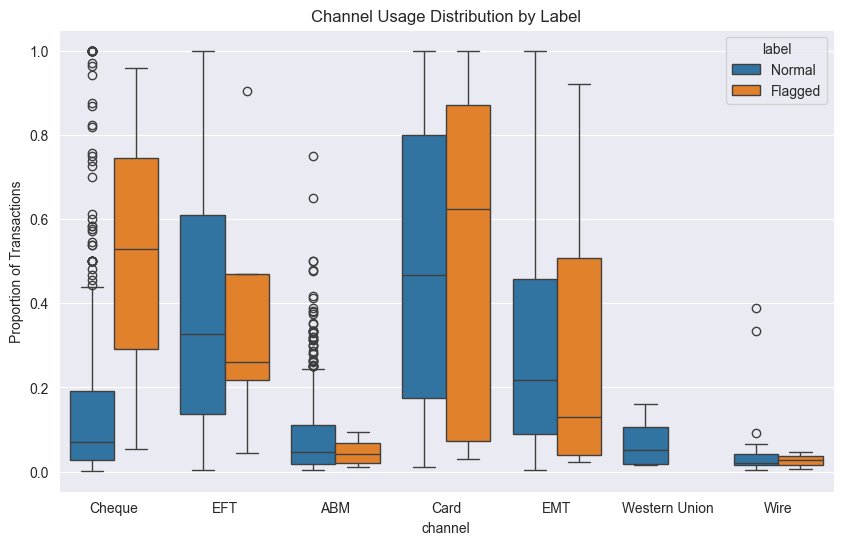

In [6]:
data["label"] = data["label"].map({0: "Normal", 1: "Flagged"})

channel_usage = (
    data.groupby(["customer_id", "channel"])
    .size()
    .reset_index(name="count")
)

# convert to proportions
channel_usage["prop"] = (
    channel_usage.groupby("customer_id")["count"]
    .transform(lambda x: x / x.sum())
)

# attach label
labels = data[["customer_id", "label"]].drop_duplicates()

channel_usage = channel_usage.merge(labels, on="customer_id")

plt.figure(figsize=(10,6))
sns.boxplot(
    data=channel_usage,
    x="channel",
    y="prop",
    hue="label")
plt.title("Channel Usage Distribution by Label")
plt.ylabel("Proportion of Transactions")
# plt.savefig("channel_usage.png", bbox_inches="tight")
plt.show()

# Part 2: Basic Statistics

In [7]:
customer_labels = data[["customer_id", "label"]].drop_duplicates()
customer_counts = customer_labels["label"].value_counts()
customer_counts_df = customer_counts.reset_index()
customer_counts_df.columns = ["label", "num_customers"]
customer_counts

label
Normal     990
Flagged     10
Name: count, dtype: int64

In [8]:
tx_counts = data.groupby("label").size()
tx_counts_df = tx_counts.reset_index()
tx_counts_df.columns = ["label", "num_transactions"]
tx_counts_df

,label,num_transactions
0,Flagged,754
1,Normal,57956


In [9]:
tx_per_customer = (
    data.groupby("customer_id")
    .size()
    .reset_index(name="tx_count"))

tx_per_customer = tx_per_customer.merge(customer_labels, on="customer_id")
tx_per_customer.groupby("label")["tx_count"].describe()

,count,mean,std,min,25%,50%,75%,max
label,,,,,,,,
Flagged,10.0,75.400000,54.002469,3.0,35.75,62.5,123.5,161.0
Normal,990.0,58.541414,65.506765,1.0,16.00,36.5,75.0,481.0


In [10]:
channel_counts = (
    data.groupby(["label", "channel"])
    .size()
    .reset_index(name="count"))

channel_counts

,label,channel,count
0,Flagged,ABM,26
1,Flagged,Card,317
2,Flagged,Cheque,103
3,Flagged,EFT,111
4,Flagged,EMT,195
5,Flagged,Wire,2
6,Normal,ABM,1948
7,Normal,Card,31319
8,Normal,Cheque,2747
9,Normal,EFT,12895


In [11]:
len(data.customer_id.unique())

61410

In [12]:
len(data.transaction_id.unique())

5903333

# Part 3: Time between transactions

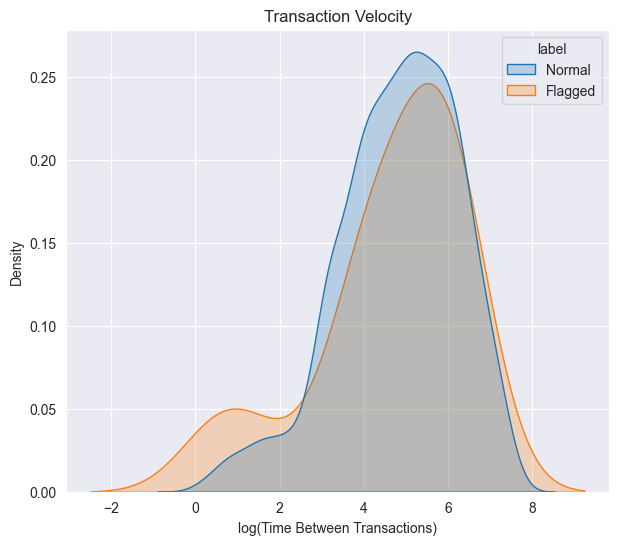

In [15]:
data["transaction_datetime"] = pd.to_datetime(
    data["transaction_datetime"],
    errors="coerce"
)

df = data.sort_values(["customer_id", "transaction_datetime"])

df["time_diff_hours"] = (
    df.groupby("customer_id")["transaction_datetime"]
    .diff()
    .dt.total_seconds() / 3600
)

df["log_time_diff"] = np.log1p(df["time_diff_hours"])

plt.figure(figsize=(7,6))
sns.kdeplot(
    data=df,
    x="log_time_diff",
    hue="label",
    common_norm=False,
    fill=True
)
plt.title("Transaction Velocity")
plt.xlabel("log(Time Between Transactions)")
# plt.savefig("transaction_velocity.png", bbox_inches="tight")
plt.show()

# Part 4: Engineered feature EDA

/var/folders/h2/wp9729hs033gv8ywbz5q4b_h0000gn/T/ipykernel_46667/1036436915.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


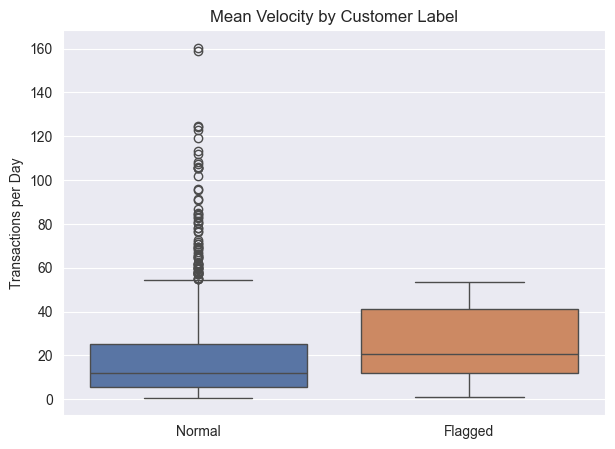

In [25]:
plot_df = all_features.copy()
plot_df["label"] = plot_df["label"].map({0: "Normal", 1: "Flagged"})

plt.figure(figsize=(7,5))

# Boxplot
sns.boxplot(
    data=plot_df,
    x="label",
    y="mean_velocity",
    palette={"Normal": "#4C72B0", "Flagged": "#DD8452"}
)

plt.title("Mean Velocity by Customer Label")
plt.xlabel("")
plt.ylabel("Transactions per Day")
# plt.savefig("mean_velocity.png")
plt.show()